### Explainability with Grad-CAM on DenseNet121

Correct samples found for 44/44 classes.
Incorrect samples found for 10/44 classes.


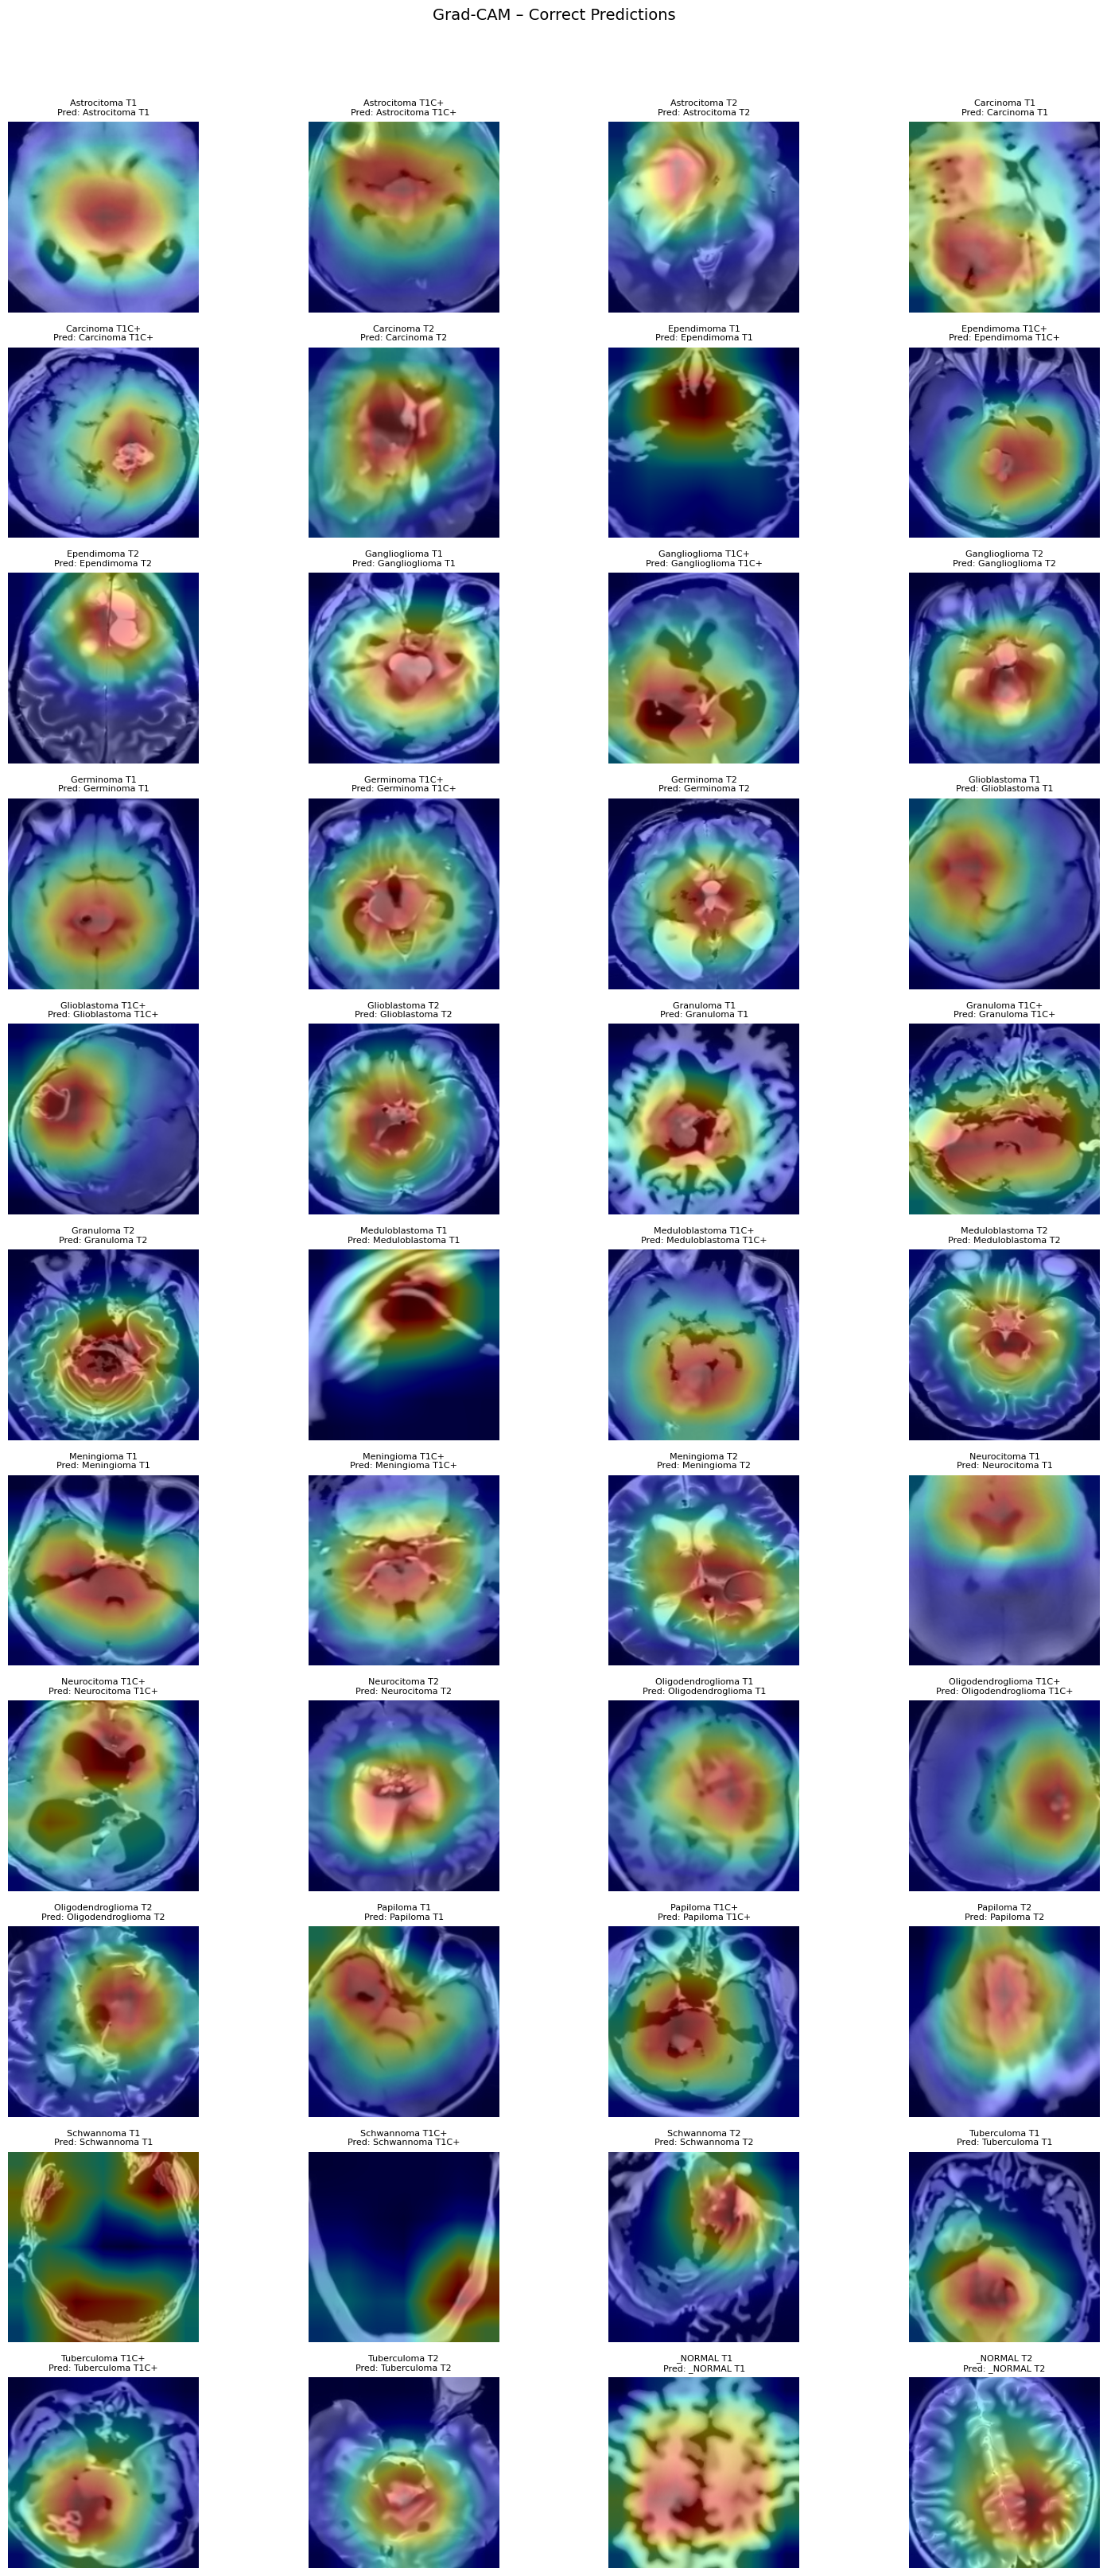

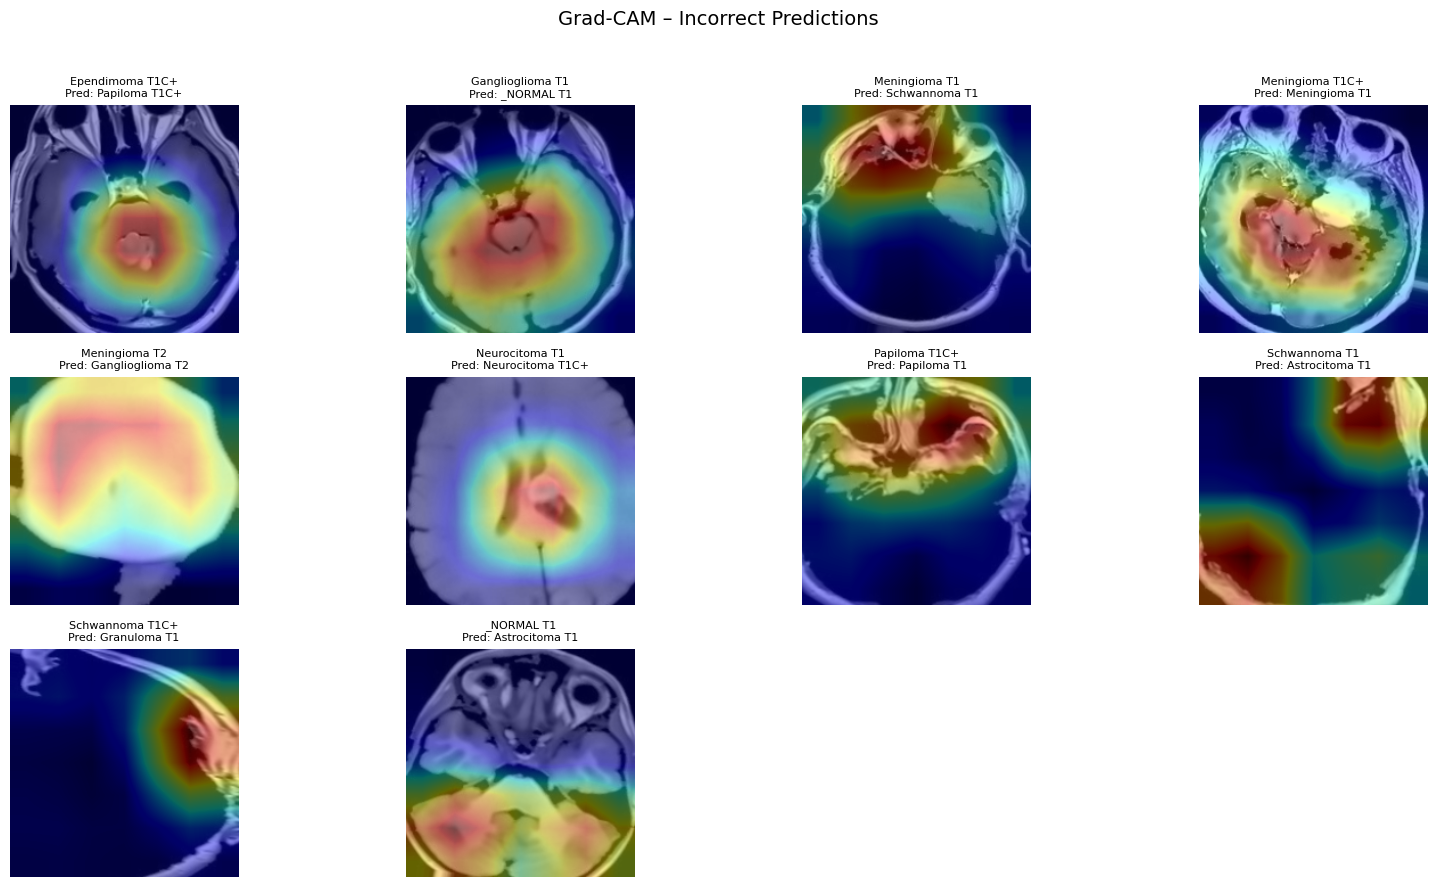

In [19]:
import math
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

model.eval()
target_layer = model.features.norm5  # last feature layer in DenseNet121


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_backward_hook(backward_hook)

    def generate(self, x, class_idx=None):
        self.model.zero_grad()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
        score = logits[0, class_idx]
        score.backward()

        grads = self.gradients[0]
        acts  = self.activations[0]

        weights = grads.mean(dim=(1, 2))
        cam = (weights[:, None, None] * acts).sum(dim=0)
        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam.cpu().numpy()


def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1).to(img_tensor.device)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1).to(img_tensor.device)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    img = img.detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    return img


grad_cam = GradCAM(model, target_layer)

# one correct and one incorrect sample per class (if available)
correct_samples = {}    
incorrect_samples = {}

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        targets = targets.to(device)
        preds = model(images).argmax(dim=1)

        for img, y, p in zip(images, targets, preds):
            c = int(y.item())
            p_c = int(p.item())

            if y == p and c not in correct_samples:
                correct_samples[c] = (img.cpu(), c, p_c)

            if y != p and c not in incorrect_samples:
                incorrect_samples[c] = (img.cpu(), c, p_c)

        if len(correct_samples) == num_classes and len(incorrect_samples) == num_classes:
            break

print(f"Correct samples found for {len(correct_samples)}/{num_classes} classes.")
print(f"Incorrect samples found for {len(incorrect_samples)}/{num_classes} classes.")


def plot_gradcam_grid(samples_dict, title_prefix):
    if not samples_dict:
        print(f"No samples for {title_prefix}.")
        return

    n_classes = len(samples_dict)
    n_cols = 4
    n_rows = math.ceil(n_classes / n_cols)

    plt.figure(figsize=(4 * n_cols, 3 * n_rows))

    for idx, class_idx in enumerate(sorted(samples_dict.keys())):
        img, y_true, y_pred = samples_dict[class_idx]

        x = img.unsqueeze(0).to(device)
        cam = grad_cam.generate(x, class_idx=y_pred)

        base = denormalize(img)
        cam_resized = F.interpolate(
            torch.tensor(cam)[None, None, ...],
            size=base.shape[:2],
            mode="bilinear",
            align_corners=False
        )[0, 0].numpy()

        ax = plt.subplot(n_rows, n_cols, idx + 1)
        ax.imshow(base)
        ax.imshow(cam_resized, cmap="jet", alpha=0.4)
        ax.axis("off")
        ax.set_title(
            f"{class_names[y_true]}\nPred: {class_names[y_pred]}",
            fontsize=8
        )

    plt.suptitle(title_prefix, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_gradcam_grid(correct_samples, "Grad-CAM – Correct Predictions")

plot_gradcam_grid(incorrect_samples, "Grad-CAM – Incorrect Predictions")


### Train Test Splitting for new dataset(Best Model DenseNet 121)

In [23]:
import os, shutil, random

input_dir = "/kaggle/input/new-dataset"
output_base = "/kaggle/working/brain-tumor-mri-split_New"
splits = ["train","val","test"]
ratios = [0.7,0.15,0.15]

for s in splits:
    for cls in os.listdir(input_dir):
        os.makedirs(os.path.join(output_base,s,cls), exist_ok=True)

for cls in os.listdir(input_dir):
    cls_path = os.path.join(input_dir, cls)
    if not os.path.isdir(cls_path): continue
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(files)
    n = len(files)
    n_train, n_val = int(n*ratios[0]), int(n*ratios[1])
    train_files = files[:n_train]
    val_files = files[n_train:n_train+n_val]
    test_files = files[n_train+n_val:]
    for f in train_files:
        shutil.copy(os.path.join(cls_path,f), os.path.join(output_base,"train",cls,f))
    for f in val_files:
        shutil.copy(os.path.join(cls_path,f), os.path.join(output_base,"val",cls,f))
    for f in test_files:
        shutil.copy(os.path.join(cls_path,f), os.path.join(output_base,"test",cls,f))

def count_images(path):
    total = 0
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if not os.path.isdir(cls_path): continue
        total += len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return total

print("✅ Split complete. Data saved to", output_base)
print("Train:", count_images(os.path.join(output_base,"train")))
print("Val:", count_images(os.path.join(output_base,"val")))
print("Test:", count_images(os.path.join(output_base,"test")))

✅ Split complete. Data saved to /kaggle/working/brain-tumor-mri-split_New
Train: 2782
Val: 849
Test: 861


### Best Model(DenseNet 121) evaluation on new dataset

In [25]:
import os, time, random, numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_root = "/kaggle/working/brain-tumor-mri-split_New"
train_dir = os.path.join(data_root, "train")
val_dir   = os.path.join(data_root, "val")
test_dir  = os.path.join(data_root, "test")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
img_size = 224

train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(img_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir,   transform=eval_tfms)
test_ds  = datasets.ImageFolder(test_dir,  transform=eval_tfms)

class_names = train_ds.classes
num_classes = len(class_names)

batch_size = 32
num_workers = 2
pin_memory = torch.cuda.is_available()

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                                           num_workers=num_workers, pin_memory=pin_memory)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                                           num_workers=num_workers, pin_memory=pin_memory)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                                           num_workers=num_workers, pin_memory=pin_memory)

weights = models.DenseNet121_Weights.IMAGENET1K_V1
model = models.densenet121(weights=weights)
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, num_classes)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

def print_model_summary(m, input_size=(1, 3, img_size, img_size)):
    try:
        from torchinfo import summary
        print(summary(m, input_size=input_size,
                      col_names=("input_size","output_size","num_params","trainable")))
    except Exception:
        print(m)
        total_params = sum(p.numel() for p in m.parameters())
        trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f"Total params: {total_params:,}")
        print(f"Trainable params: {trainable_params:,}")

epochs = 40
patience = 5
best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None

def run_epoch(loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        if train_mode:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train_mode):
            outputs = model(images)
            loss = criterion(outputs, targets)
            if train_mode:
                loss.backward()
                optimizer.step()
        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * images.size(0)
        running_correct += (preds == targets).sum().item()
        total += images.size(0)
    epoch_loss = running_loss / max(total, 1)
    epoch_acc = running_correct / max(total, 1)
    return epoch_loss, epoch_acc

t_train_start = time.time()
for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break
t_train_end = time.time()
train_time_s = t_train_end - t_train_start

if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

print("\nModel summary (post-training):")
print_model_summary(model)

@torch.no_grad()
def collect_preds(loader):
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets.numpy())
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return all_targets, all_preds

@torch.no_grad()
def collect_preds_and_probs(loader):
    model.eval()
    all_probs, all_preds, all_targets = [], [], []
    for images, targets in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1).cpu().numpy()
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds)
        all_targets.append(targets.numpy())
    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return all_targets, all_preds, all_probs

def plot_roc_auc(y_true, y_prob, labels, title):
    y_true_bin = label_binarize(y_true, classes=list(range(len(labels))))
    macro_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
    micro_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="micro")
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"ROC (micro/macro AUC={micro_auc:.3f}/{macro_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Macro AUC: {macro_auc:.4f} | Micro AUC: {micro_auc:.4f}")

print("\nClassification report - TRAIN:")
y_true_tr, y_pred_tr = collect_preds(train_loader)
print(classification_report(y_true_tr, y_pred_tr, target_names=class_names,
                            zero_division=0, digits=4))

print("\nClassification report - VAL:")
y_true_va, y_pred_va = collect_preds(val_loader)
print(classification_report(y_true_va, y_pred_va, target_names=class_names,
                            zero_division=0, digits=4))

print("\nClassification report - TEST:")
t_test_start = time.time()
y_true_te, y_pred_te, y_prob_te = collect_preds_and_probs(test_loader)
t_test_end = time.time()
test_time_s = t_test_end - t_test_start
print(classification_report(y_true_te, y_pred_te, target_names=class_names,
                            zero_division=0, digits=4))

cm = confusion_matrix(y_true_te, y_pred_te, labels=range(num_classes))
plt.figure(figsize=(12, 12))
sns.heatmap(cm, cmap="Blues", cbar=True, square=True,
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.title("DenseNet121_TL - Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

plot_roc_auc(y_true_te, y_prob_te, class_names,
             "DenseNet121_TL - ROC Curve (Micro/Macro)")

@torch.no_grad()
def measure_inference_time(dataset, max_samples=100):
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    indices = indices[:min(max_samples, len(indices))]
    single_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(dataset, indices),
        batch_size=1, shuffle=False, num_workers=0, pin_memory=pin_memory
    )
    if device.type == "cuda":
        torch.cuda.empty_cache()
    for i, (x, _) in enumerate(single_loader):
        x = x.to(device)
        _ = model(x)
        if i >= 5:
            break
    start = time.time()
    for x, _ in single_loader:
        x = x.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        _ = model(x)
        if device.type == "cuda":
            torch.cuda.synchronize()
    end = time.time()
    n = len(indices)
    return (end - start) / n if n > 0 else float("nan")

avg_inf_s = measure_inference_time(test_ds, max_samples=100)

print(f"\nTiming:")
print(f"Training time: {train_time_s:.2f} s")
print(f"Testing time (test set evaluation): {test_time_s:.2f} s")
print(f"Average inference time per image: {avg_inf_s*1000:.2f} ms")


FileNotFoundError: Found no valid file for the classes Brain Tumor Data(1), dataset.csv. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp